# Missing Data Analysis 

This notebook performs analysis of missing data in a specified population (i.e. checking missing data per item and construct). It also performs multiple imputations on selected items.

In [139]:
import pandas as pd
import numpy as np

Sample  1

In [140]:
data = pd.read_excel("/Users/henrysalgado/Desktop/Coache Data Analysis/Samples/sample1_hsi_stem_instructional.xlsx")
data.describe()

,demo_inst_id,hacu_hsi,demo_tenure,demo_rank,demo_race,demo_gender,demo_is_clinical,demo_is_parent_any,demo_is_parent_itp,demo_is_parent_k12,...,q270b_18,q270b_19,q270b_20,q270b_21,q270b_22,q270b_23,q270b_24,q270b_25,q270b_98,q305
count,971.000000,971.0,971.000000,971.000000,968.000000,971.000000,920.0,970.000000,970.000000,970.000000,...,971.0,971.0,971.0,971.0,971.0,971.0,971.0,971.0,971.0,467.000000
mean,295.385170,1.0,1.781668,2.324408,3.733471,1.911432,0.0,0.482474,0.148454,0.284536,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.438972
std,61.934851,0.0,0.880320,1.680946,11.036708,5.754638,0.0,0.499951,0.355732,0.451426,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.496794
min,126.000000,1.0,1.000000,1.000000,1.000000,1.000000,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
25%,303.000000,1.0,1.000000,1.000000,2.000000,1.000000,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
50%,315.000000,1.0,1.000000,2.000000,2.000000,2.000000,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
75%,319.000000,1.0,3.000000,3.000000,2.000000,2.000000,0.0,1.000000,0.000000,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000
max,404.000000,1.0,3.000000,9.000000,91.000000,91.000000,0.0,1.000000,1.000000,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000


Let's analize missing data. For this, let's first tag 96 - 99 values as non-response codes. 

In [141]:
non_response_codes = [96, 97, 98, 99]
data.replace(non_response_codes, np.nan, inplace=True)

The following constructs are tentative, the purpose is 1) remove items with more than 20% missing data to minimize bias introduction  Rubin 1987 ; Enders 2003

In [142]:
import pandas as pd

missing_threshold = 0.30


features_of_interest = [
    # Chair Support
    "q185h", "q185i", "q185j", "q185k", "q185l",
    # Institutional Resources
    "q90a", "q90c", "q90d", "q90e", "q90f", "q90h",
    # Recognition
    "q215a", "q215b", "q215c", "q215e", "q215d", "q215i", "q215l",
    # Worklife Balance
     "q200a", "q200b", "q200c", "q200d",
    # Compensation and Benefits
    "q90g", "q95a", "q95b", "q95c", "q95d", "q95e", "q95f", "q95h", "q95i", "q95j", "q95k", "q95l", "q95m", "q95n",
    # Relatedness
    "q210c", "q212a", "q105a", "q105e", "q205c",
    # Competence
    "q45a", "q45c", "q45d", "q45e",
    # Autonomy
    "q188b", "q188a", "q186d",
    #Mentoring
    "q120a", "q120b", "q120c",
    #Promotion NTT"
    'q460a', 'q460b', 'q460c', 'q460d', 'q460e',
    # Service Satisfaction
    "q60a","q60b", "q60c", "q60d", "q60e" ,"q60f", "q60g","q60h", "q60i",
    # Teaching
      "q70a", "q70b", "q70c", "q70d", "q70e", "q70f", "q70h", "q70k", "q70l", "q70m", "q70n",
    # Global Satisfaction
    "q245d", "q250a", "q250b"
]

print("Number of Total Features of Interest:", len(features_of_interest))


valid_features = [
    feature for feature in features_of_interest
    if feature in data.columns and data[feature].isna().mean() < missing_threshold
]

print(f"Number of Valid Features under {missing_threshold*100:.0f} %:", len(valid_features))


constructs = {
    'chair_support': ["q185h", "q185i", "q185j", "q185k", "q185l"],
    'institutional_support': ["q90a", "q90c", "q90d", "q90e", "q90f", "q90h"],
    'dep_feed_and_rec': ["q215a", "q215b", "q215c", "q215e", "q215d", "q215i", "q215l"],
    'worklife_balance': ["q55a", "q55b", "q200a", "q200b", "q200c", "q200d"],
    'compensation_benefits': ["q90g", "q95a", "q95b", "q95c", "q95d", "q95e", "q95f", "q95h", "q95i", "q95j", "q95k", "q95l", "q95m", "q95n"],
    'autonomy': ["q188b", "q188a", "q186d"],
    'mentoring': ["q120a", "q120b", "q120c"],
    "Promotion NTT": ['q460a', 'q460b', 'q460c', 'q460d', 'q460e'],
    'relatedness': ["q210c", "q212a", "q105a", "q105e", "q205c"],
    'time_competence': ["q45a", "q45c", "q45d", "q45e"],
    'Service_satisfaction': ["q60a","q60b", "q60c", "q60d", "q60e" ,"q60f", "q60g","q60h", "q60i"],
    'Teaching_satisfaction': [ "q70a", "q70b", "q70c", "q70d", "q70e", "q70f", "q70h", "q70k", "q70l", "q70m", "q70n"],
    'global_satisfaction': ['q245d', 'q250a', 'q250b']
}


def calculate_average_missingness(items):
    valid_items = [item for item in items if item in valid_features]
    invalid_items = [item for item in items if item not in valid_features]

    if not valid_items:
        return invalid_items
    return data[valid_items].isna().mean().mean()


print("\nAverage missingness for constructs (using valid features):")

for construct, items in constructs.items():
    avg = calculate_average_missingness(items)
    if isinstance(avg, list): 
        print(f"{construct}: No valid items below threshold. Missing: {avg}")
    else:
        print(f"{construct}: {avg:.2%}")


Number of Total Features of Interest: 79
Number of Valid Features under 30 %: 60

Average missingness for constructs (using valid features):
chair_support: 15.92%
institutional_support: 7.02%
dep_feed_and_rec: 20.48%
worklife_balance: 20.85%
compensation_benefits: 13.75%
autonomy: 26.40%
mentoring: 12.94%
Promotion NTT: No valid items below threshold. Missing: ['q460a', 'q460b', 'q460c', 'q460d', 'q460e']
relatedness: 13.99%
time_competence: 7.72%
Service_satisfaction: 20.85%
Teaching_satisfaction: 10.22%
global_satisfaction: 15.83%


Function to see missingness per item

In [143]:
def print_item_and_average_missingness(construct):
    if construct not in constructs:
        print(f"Construct '{construct}' not found.")
        return
    items = [item for item in constructs[construct] if item in valid_features]
    if not items:
        print(f"No valid items for construct '{construct}'.")
        return
    missing_values = data[items].isna().mean() * 100
    print(f"\nMissingness for {construct}:")
    for item, missingness in missing_values.items():
        print(f"  {item}: {missingness:.2f}%")
    print(f"Average missingness for {construct}: {missing_values.mean():.2f}%\n")


print_item_and_average_missingness('autonomy')



Missingness for autonomy:
  q188b: 25.03%
  q188a: 27.29%
  q186d: 26.88%
Average missingness for autonomy: 26.40%



# Multiple Imputation 
Using these valid features, we will use Multiple Imputation to fill in these missing values. Little and Rubin 2002 

In [144]:
import miceforest as mf

kds = mf.ImputationKernel(
    data[valid_features],
    save_all_iterations=True,

)

kds.mice(iterations=5) 


completed_data_model_vars = kds.complete_data(0)


completed_data = data.copy()
completed_data[valid_features] = completed_data_model_vars

# This option saves imputed data + all other variables

completed_data.to_csv('/Users/henrysalgado/Desktop/Coache Data Analysis/sample1_30missing_complete_imputed_data.csv', index=False)

# This option saves only the valid variables that cleared the threshold
completed_data_model_vars.to_csv('/Users/henrysalgado/Desktop/Coache Data Analysis/ImputerData/sample1_30imputed.csv',index = False)
print('Data Imputed on Valid Features - Saved as CSV')

Data Imputed on Valid Features - Saved as CSV


In [145]:
completed_data_model_vars.shape

(971, 60)

In [146]:
import pandas as pd


main_df = pd.read_csv("/Users/henrysalgado/Desktop/Coache Data Analysis/ImputerData/sample1_imputed.csv")     
key_df = pd.read_excel("Variables.xlsx")       # the file with 'key' and 'name' columns


key_df['key'] = key_df['key'].str.lower()


rename_dict = dict(zip(key_df['key'], key_df['name']))


main_df.rename(columns=lambda col: rename_dict.get(col.lower(), col), inplace=True)


#main_df.to_csv("Sample1_labeled.csv", index=False)


In [147]:
main_df

,Head/Chair: Pace of decision making,Head/Chair: Stated priorities,Head/Chair: Communication of priorities,Head/Chair: Ensuring faculty input,Head/Chair: Fairness in evaluating work,Office,Equipment,Classrooms,Library resources,Computing and technical support,...,Level of courses taught,Discretion over course content,Number of students in classes taught,Quality of students taught,Support for improving teaching,Equitability of distribution of teaching load,Support for assessing student learning,I would again choose this institution,Department as a place to work,Institution as a place to work
0,5.0,5.0,5.0,5.0,5.0,4.0,4.0,4.0,5.0,5.0,...,5.0,5.0,4.0,4.0,3.0,3.0,3.0,4.0,5.0,5.0
1,5.0,5.0,5.0,5.0,5.0,4.0,4.0,3.0,3.0,5.0,...,3.0,3.0,3.0,3.0,4.0,2.0,3.0,4.0,4.0,3.0
2,3.0,3.0,3.0,4.0,5.0,2.0,3.0,2.0,4.0,3.0,...,4.0,5.0,2.0,3.0,2.0,2.0,3.0,2.0,3.0,3.0
3,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,...,5.0,5.0,5.0,4.0,4.0,4.0,4.0,5.0,5.0,5.0
4,4.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,4.0,3.0,...,4.0,3.0,3.0,3.0,3.0,2.0,3.0,4.0,4.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
966,3.0,2.0,3.0,3.0,3.0,2.0,5.0,2.0,3.0,4.0,...,5.0,1.0,5.0,2.0,5.0,5.0,3.0,4.0,4.0,4.0
967,5.0,5.0,5.0,5.0,5.0,4.0,4.0,4.0,3.0,4.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,5.0,5.0
968,5.0,5.0,5.0,5.0,5.0,2.0,3.0,1.0,4.0,3.0,...,4.0,4.0,4.0,4.0,3.0,4.0,3.0,5.0,5.0,3.0
969,3.0,3.0,3.0,3.0,3.0,3.0,5.0,5.0,3.0,5.0,...,4.0,4.0,4.0,3.0,5.0,4.0,3.0,4.0,4.0,4.0


# EFA 

In [148]:
from factor_analyzer import FactorAnalyzer
import pandas as pd
import matplotlib as plt


#df = completed_data[valid_features].copy()
df = completed_data_model_vars


from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

bartlett_chi_square_value, p_value = calculate_bartlett_sphericity(df)
print("Bartlett's Test: ", p_value)

kmo_all, kmo_model = calculate_kmo(df)
print("KMO Test: ", kmo_model)


fa = FactorAnalyzer(n_factors=8, rotation='varimax')
fa.fit(df)

# View factor loadings
loadings = pd.DataFrame(fa.loadings_, index=df.columns)
print(loadings)


Bartlett's Test:  0.0
KMO Test:  0.9656668502702258


/Users/henrysalgado/opt/anaconda3/lib/python3.8/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


              0         1         2         3         4         5         6  \
q185h  0.178820  0.828447  0.185241  0.181615  0.111690  0.113864  0.065591   
q185i  0.161859  0.864564  0.165732  0.167213  0.129647  0.114020  0.068785   
q185j  0.145474  0.871558  0.190714  0.169520  0.132884  0.130105  0.035126   
q185k  0.123405  0.832364  0.211596  0.188424  0.152543  0.093945  0.054596   
q185l  0.157957  0.768704  0.317722  0.198052  0.197608  0.041542  0.067452   
q90a   0.481847  0.184578  0.118370  0.032120  0.103773  0.036115  0.229731   
q90c   0.613127  0.155324  0.149259  0.087884  0.090907  0.189568  0.183652   
q90d   0.526078  0.126148  0.114465  0.056802  0.120901  0.212632  0.141834   
q90e   0.523420  0.091578  0.143246  0.067562  0.039005  0.167612  0.229231   
q90f   0.506362  0.173785  0.079528  0.082111  0.083449  0.203592  0.223403   
q90h   0.557198  0.250972  0.029056  0.099992  0.142286  0.087108  0.179520   
q215a  0.249460  0.269698  0.373826  0.195102  0.637

In [149]:
from factor_analyzer import FactorAnalyzer
import matplotlib.pyplot as plt

# Fit model without specifying number of factors
fa = FactorAnalyzer()
fa.fit(df)

# Get eigenvalues
eigenvalues, _ = fa.get_eigenvalues()


In [150]:
eigenvalues

array([23.30547927,  3.84432286,  2.22984674,  2.00280106,  1.89787479,
        1.45406988,  1.41334944,  1.36389725,  1.24732584,  1.10555553,
        0.95994133,  0.92186394,  0.88972276,  0.79359093,  0.73163627,
        0.70915254,  0.69841345,  0.64139203,  0.63326961,  0.60069065,
        0.57903549,  0.56908671,  0.55649424,  0.54581254,  0.5390623 ,
        0.50342357,  0.48726575,  0.47664553,  0.45421607,  0.43562508,
        0.42689284,  0.40057906,  0.38199183,  0.37159926,  0.35412325,
        0.34686254,  0.33466577,  0.32877228,  0.30939408,  0.30044103,
        0.29651735,  0.27817652,  0.26790084,  0.2604749 ,  0.25144438,
        0.24543469,  0.23648216,  0.2089372 ,  0.20314133,  0.19995368,
        0.18881893,  0.16867822,  0.161016  ,  0.15218711,  0.14331537,
        0.14214336,  0.12744108,  0.12509918,  0.11463262,  0.08201971])

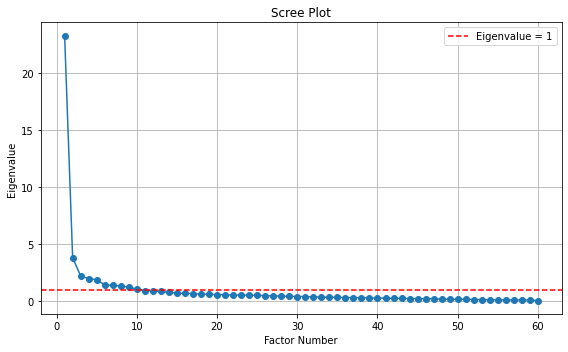

In [151]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, marker='o')
plt.title('Scree Plot')
plt.xlabel('Factor Number')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.axhline(y=1, color='r', linestyle='--', label='Eigenvalue = 1')
plt.legend()
plt.tight_layout()
plt.show()


In [152]:
import semopy
from semopy import Model, semplot


# Define the SEM model
model_desc = '''
# Measurement model
chair_suprt =~ q185h + q185i + q185j + q185k + q185l 
inst_suprt =~ q90a + q90c + q90d + q90e + q90f + q90h + q95c
recog_suprt =~ q215a + q215d + q215l
work_life_suprt =~ q200a  

relatedness =~ q205c + q210c + q212a + q105a + q105e + q215i

service =~ q45c + q60a + q60c + q60d + q60e
teaching =~ q45a + q70a + q70b + q70c + q70d + q70e

global_sat =~ q250a + q250b + q245d

# Regressions

global_sat ~ chair_suprt + inst_suprt + recog_suprt + work_life_suprt + teaching + service + relatedness

'''

# Fit the model
model = semopy.Model(model_desc)
res = model.fit(df, obj = "DWLS")  # Use 'MLW' (Weighted Least Squares) as MLR/FIML alternative
print(res)

Name of objective: DWLS
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 1.020
Number of iterations: 94
Params: 1.025 1.049 1.101 1.093 1.186 1.042 0.791 1.028 1.098 0.749 1.007 1.061 0.933 0.927 0.811 0.673 0.825 0.907 1.129 1.234 1.047 1.258 1.166 1.179 1.088 1.108 0.910 1.000 0.449 0.400 -0.886 1.673 -0.616 -0.525 0.673 1.126 0.342 0.456 0.077 0.503 0.528 0.578 0.247 0.259 0.249 0.316 0.140 1.087 0.512 0.533 0.530 0.461 0.385 0.459 0.492 0.470 0.209 0.318 0.503 0.553 0.404 0.509 0.631 0.478 0.657 0.483 0.472 0.890 0.795 0.839 0.509 0.707 0.507 0.668 0.640 0.592 0.974 0.788 0.408 0.505 0.873 0.669 0.411 0.760 0.470 0.496 0.335 0.390 0.270 0.331 0.353 0.339 0.325 0.403 0.632 0.422 0.350 0.672 0.535 0.448


In [153]:
ins = model.inspect()
print(ins)


           lval  op             rval  Estimate        Std. Err    z-value  \
0    global_sat   ~      chair_suprt  0.448583    304529.77411   0.000001   
1    global_sat   ~       inst_suprt  0.399995   251154.223845   0.000002   
2    global_sat   ~      recog_suprt -0.886027   845115.880343  -0.000001   
3    global_sat   ~  work_life_suprt  1.673228  1272978.760084   0.000001   
4    global_sat   ~         teaching -0.616139   798668.340117  -0.000001   
..          ...  ..              ...       ...             ...        ...   
103        q90d  ~~             q90d  0.707077        0.036136  19.567024   
104        q90e  ~~             q90e  0.506862        0.025277  20.052459   
105        q90f  ~~             q90f  0.667710        0.034264  19.487355   
106        q90h  ~~             q90h  0.639881        0.033686  18.995316   
107        q95c  ~~             q95c  0.591525        0.028833  20.515253   

      p-value  
0    0.999999  
1    0.999999  
2    0.999999  
3    0.9999

In [154]:
stats = semopy.calc_stats(model)
print(stats.T)

                      Value
DoF              566.000000
DoF Baseline     630.000000
chi2             990.749457
chi2 p-value       0.000000
chi2 Baseline  73561.429416
CFI                0.994176
GFI                0.986532
AGFI               0.985009
NFI                0.986532
TLI                0.993518
RMSEA              0.027815
AIC              192.872918
BIC              680.705565
LogLik             3.563541


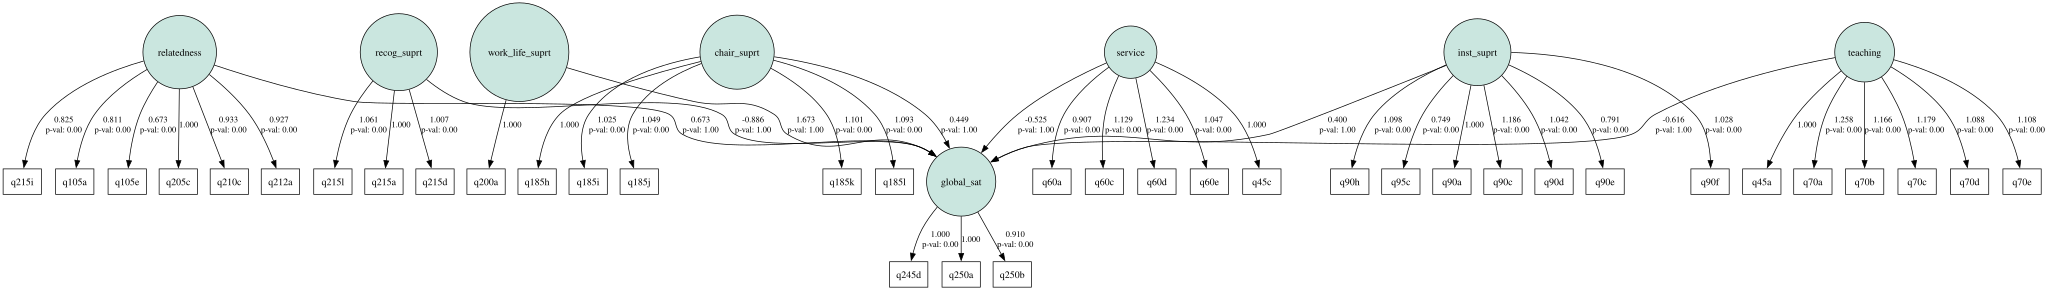

In [155]:
graph = semopy.semplot(model, "test.png")
graph